# Домашнее задание №3: ислледование KNN
---
## 1. Первичный анализ данных (описание датасета)
### Star dataset to predict star types

**Ссылка для скачивания:**  
https://www.kaggle.com/datasets/deepu1109/star-dataset?resource=download

### О датасете
- **240 записей**, 6 признаков (4 числовых + 2 категориальных)
- **Целевая переменная:** `Star type` 6 классов: 
    - 0 - Коричневый карлик (Brown Dwarf), 
    - 1 - Красный карлик (Red Dwarf), 
    - 2 - Белый карлик (White Dwarf), 
    - 3 - Главная последовательность (Main Sequence),
    - 4 - Сверхгигант (Supergiant),
    - 5 - Гипергигант (Hypergiant))
- **Описание признаков:**

| Признак | Описание | Тип |
|---------|----------|-----|
| **Temperature (K)** | Абсолютная температура в Кельвинах | Числовой (int) |
| **Luminosity(L/Lo)** | Светимость относительно Солнца | Числовой (float) |
| **Radius(R/Ro)** | Радиус относительно Солнца | Числовой (float) |
| **Absolute magnitude(Mv)** | Абсолютная звёздная величина | Числовой (float) |
| **Star color** | Цвет звезды (white, Red, Blue, Yellow, yellow-orange и др.) | Категориальный (str) |
| **Spectral Class** | Спектральный класс (M, B, O, A, F, K, G) | Категориальный (str) |

- **Пропусков нет - все 240 записей содержат полные данные по всем признакам**
- **Распределение классов:**

| Star Type | Количество |
|:---------:|:--------:|
| 0 | 40 |
| 1 | 40 |
| 2 | 40 |
| 3 | 40 |
| 4 | 40 |
| 5 | 40 |

- **Сбалансированные классы** - по 40 объектов каждого типа

- **Возможные проблемы в данных:**
    - Сильная "Скошенность" распределений (есть выбросы):
        - **Luminosity:** 75% звезд имеют светимость < 198 000, но есть выбросы до 849 420
        - **Radius:** 75% звезд имеют радиус < 42.75, но есть гиганты с радиусом 1948.5

    **Возможное решение:** увеличение параметра k для сглаживания влияния выбросов; взвешенный поиск
    - Разные масштабы признаков:

| Признак | min | max | Размах |
|---------|-----|-----|--------|
| Temperature | 1 939 | 40 000 | ~38 000 |
| Luminosity | 0.00008 | 849 420 | ~850 000 |
| Radius | 0.0084 | 1 948.5 | ~1 948 |
| Absolute magnitude | -11.92 | 20.06 | ~32 |

**Решение:** используем масштабирование признаков (StandardScaler или MinMaxScaler), приводя все признаки к одному масштабу.

- **Структура данных:**

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df = pd.read_csv("6 class csv.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    str    
 6   Spectral Class          240 non-null    str    
dtypes: float64(3), int64(2), str(2)
memory usage: 13.3 KB


**Первые 10 строк**

In [139]:
df.head(10)

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
5,2840,0.000650,0.1100,16.98,0,Red,M
6,2637,0.000730,0.1270,17.22,0,Red,M
7,2600,0.000400,0.0960,17.40,0,Red,M
8,2650,0.000690,0.1100,17.45,0,Red,M
9,2700,0.000180,0.1300,16.05,0,Red,M


- **Базовые статистики:**

In [140]:
df.describe()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


- **Баланс классов:**

Распределение классов целевой переменной Star type:


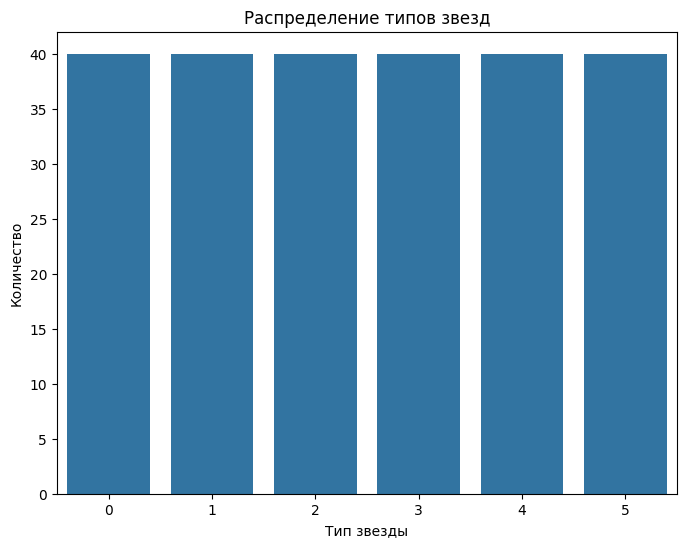

Star type
0    40
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64

In [141]:
print(f"Распределение классов целевой переменной Star type:")

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Star type')
plt.title('Распределение типов звезд')
plt.xlabel('Тип звезды')
plt.ylabel('Количество')
plt.show()

df["Star type"].value_counts()

Распределение классов Star color:


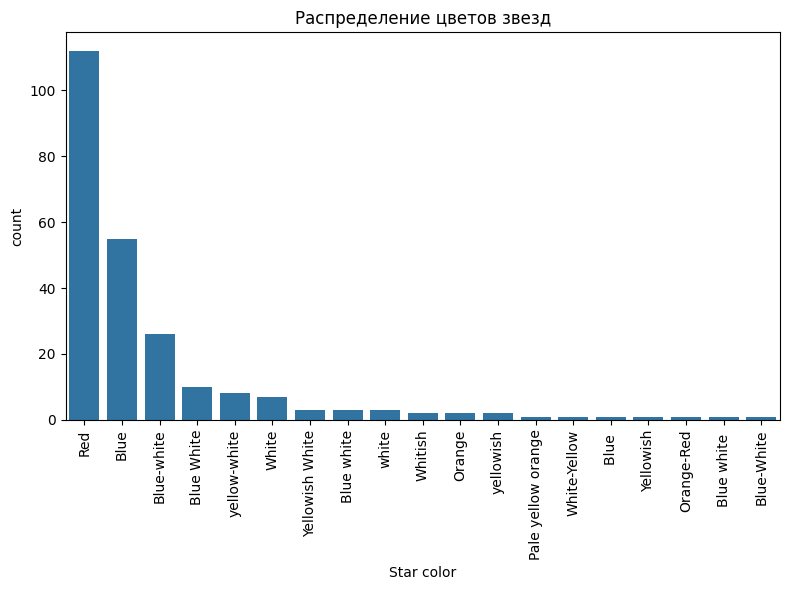

Star color
Red                   112
Blue                   55
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Yellowish White         3
Blue white              3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Blue                    1
Yellowish               1
Orange-Red              1
Blue white              1
Blue-White              1
Name: count, dtype: int64

In [142]:
print(f"Распределение классов Star color:")

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Star color',
              order=df['Star color'].value_counts().index)
plt.title('Распределение цветов звезд')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

df["Star color"].value_counts()

Некоторые цвета просто повторяются, только разная запись, поэтому их нужно почистить.
Красный, синий, сине-белый, желто-белый и белый - наиболее наблюдаемые цвета.

In [143]:
df.replace({"Star color" : {"Blue-white" : "Blue-White", 
                                  "Blue White" : "Blue-White", 
                                  "Blue white" : "Blue-White", 
                                  "Blue white " : "Blue-White", 
                                  "Blue-White" : "Blue-White",
                                  "yellow-white" : "Yellow-White",
                                  "Yellowish White" : "Yellow-White",
                                  "yellowish" : "Yellow-White",
                                  "White-Yellow" : "Yellow-White",
                                  "Yellowish" : "Yellow-White",
                                  "white" : "White",
                                  "Whitish" : "White",
                                  "Blue " : "Blue",
                                  "Pale yellow orange" : "Red",
                                  "Orange" : "Red",
                                  "Orange-Red" : "Red"}},
                                  inplace = True);

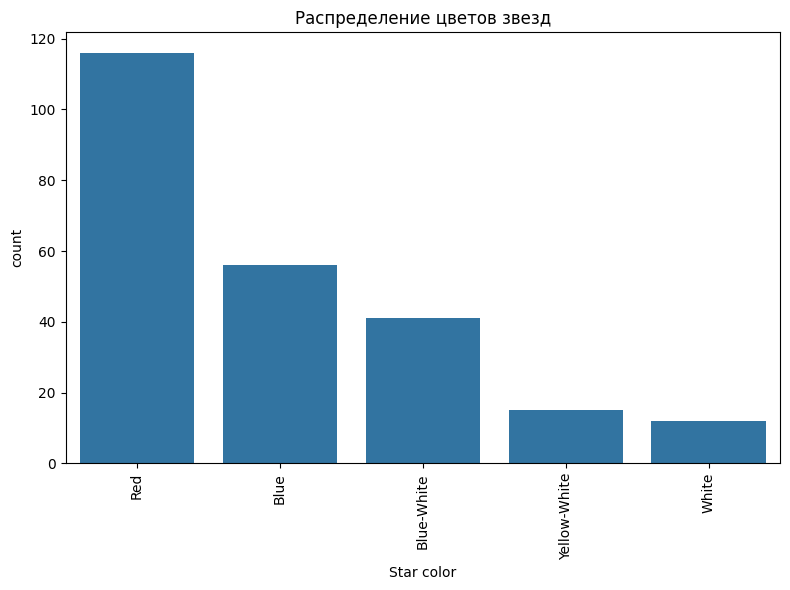

Star color
Red             116
Blue             56
Blue-White       41
Yellow-White     15
White            12
Name: count, dtype: int64

In [144]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Star color',
              order=df['Star color'].value_counts().index)
plt.title('Распределение цветов звезд')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

df['Star color'].value_counts()

Распределение классов Spectral Class:


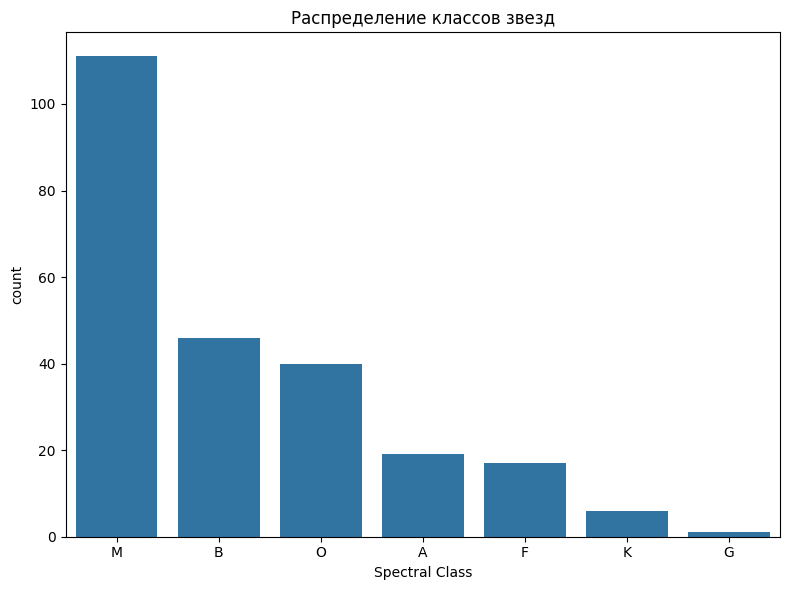

Spectral Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

In [145]:
print(f"Распределение классов Spectral Class:")

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Spectral Class',
              order=df['Spectral Class'].value_counts().index)
plt.title('Распределение классов звезд')
plt.tight_layout()
plt.show()

df["Spectral Class"].value_counts()

--- 
## 2. Подготовка данных

**Кодирование категориальных признаков**

In [147]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)

print("После кодирования:")
df.head()

После кодирования:


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color_Blue,Star color_Blue-White,Star color_Red,Star color_White,Star color_Yellow-White,Spectral Class_A,Spectral Class_B,Spectral Class_F,Spectral Class_G,Spectral Class_K,Spectral Class_M,Spectral Class_O
0,3068,0.002400,0.1700,16.12,0,0,0,1,0,0,0,0,0,0,0,1,0
1,3042,0.000500,0.1542,16.60,0,0,0,1,0,0,0,0,0,0,0,1,0
2,2600,0.000300,0.1020,18.70,0,0,0,1,0,0,0,0,0,0,0,1,0
3,2800,0.000200,0.1600,16.65,0,0,0,1,0,0,0,0,0,0,0,1,0
4,1939,0.000138,0.1030,20.06,0,0,0,1,0,0,0,0,0,0,0,1,0
